# Phase 4.5: Ensemble (Voting & Stacking)

**Tujuan:** Menggabungkan LDA, SVM RBF, Random Forest, dan XGBoost menjadi model ensemble
(Hard Voting, Soft Voting, Stacking) untuk mengevaluasi apakah kombinasi model meningkatkan
performa dibanding model tunggal.

**Validasi:** Stratified 5-Fold Cross-Validation (skor per-fold disimpan untuk uji
signifikansi lintas-fitur di 4.7).
**Output:** `output/ensemble_cv_scores.csv`, `output/ensemble_results.csv`
**Figures:** `figures/ensemble_comparison.png`


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, r"D:\Skripsi\new_data")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost is installed and will be included in the ensemble")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed - ensemble will use LDA + SVM + RF only")

PHASE3_CSV_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\csv"
OUTPUT_DIR = r"D:\Skripsi\new_data\phase_4_classification\4.5_ensemble\output"
FIG_DIR = r"D:\Skripsi\new_data\phase_4_classification\4.5_ensemble\figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


XGBoost is installed and will be included in the ensemble


In [2]:
def _feature_cols(df):
    exclude = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']
    exclude += [c for c in df.columns if 'hub_channel' in c]
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    return [c for c in cols if df[c].std() > 1e-10]

df_gc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_gc.csv"))
df_combined = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_combined.csv"))
df_spectral = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_spectral.csv"))

pdc_files = [f for f in os.listdir(PHASE3_CSV_DIR)
             if f.startswith("engineered_features_pdc_") and "broadband" not in f]

best_pdc, best_pdc_name, best_score = None, None, -1
print("Selecting best PDC band by mean ANOVA F-score:")
for f in pdc_files:
    df_pdc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, f))
    band = f.replace("engineered_features_pdc_", "").replace(".csv", "")
    feat_cols = _feature_cols(df_pdc)
    f_scores, _ = f_classif(df_pdc[feat_cols].fillna(0).values, df_pdc['class'].values)
    score = np.nanmean(f_scores)
    print(f"  PDC {band.upper():5s}: mean F-score = {score:.4f} ({len(feat_cols)} features)")
    if score > best_score:
        best_score, best_pdc, best_pdc_name = score, df_pdc, f"PDC_{band.title()}"

print(f"\nGC shape       : {df_gc.shape}")
print(f"Best PDC band  : {best_pdc_name} (shape: {best_pdc.shape})")
print(f"Combined shape : {df_combined.shape}")
print(f"Spectral shape : {df_spectral.shape}")
ROI_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\3.4_roi_aggregation\output"
df_gc_roi = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_gc_roi.csv"))
df_pdc_roi = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_pdc_roi_combined.csv"))
df_gc_pdc_roi = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_gc_pdc.csv"))
df_gc_pdc_roi_spectral = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_all.csv"))
print(f"GC_ROI shape             : {df_gc_roi.shape}")
print(f"PDC_ROI shape            : {df_pdc_roi.shape}")
print(f"GC+PDC_ROI shape         : {df_gc_pdc_roi.shape}")
print(f"GC+PDC_ROI+Spectral shape: {df_gc_pdc_roi_spectral.shape}")

Selecting best PDC band by mean ANOVA F-score:
  PDC ALPHA: mean F-score = 3.3176 (282 features)


  PDC BETA : mean F-score = 3.0740 (282 features)
  PDC DELTA: mean F-score = 3.2196 (282 features)


  PDC GAMMA: mean F-score = 2.9619 (282 features)
  PDC THETA: mean F-score = 3.4114 (282 features)

GC shape       : (675, 296)
Best PDC band  : PDC_Theta (shape: (675, 296))
Combined shape : (675, 2676)
Spectral shape : (675, 646)


GC_ROI shape             : (675, 56)
PDC_ROI shape            : (675, 306)
GC+PDC_ROI shape         : (675, 356)
GC+PDC_ROI+Spectral shape: (675, 996)


In [3]:
def prepare_features(df):
    exclude = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']
    exclude += [c for c in df.columns if 'hub_channel' in c]
    feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    feature_cols = [c for c in feature_cols if df[c].std() > 1e-10]
    # Subject-wise z-score: samakan baseline & skala tiap subjek sebelum digabung
    # lintas subjek. Tidak bocor lintas fold: hanya pakai statistik (mean/std)
    # milik subjek itu sendiri, dan grouped CV selalu menaruh semua trial 1
    # subjek di 1 sisi (train atau test), jadi transform ini independen dari fold.
    df_norm = df.copy()
    grp = df_norm.groupby('subject_id')[feature_cols]
    mean = grp.transform('mean')
    std = grp.transform('std').replace(0, np.nan)
    df_norm[feature_cols] = (df_norm[feature_cols] - mean) / std
    X = df_norm[feature_cols].fillna(0).values
    y = df['class'].values
    # NOTE: groups=subject_id agar CV tidak membocorkan trial subjek yang sama ke
    # fold train & test sekaligus (StratifiedKFold biasa bisa mencampurnya karena
    # data 675 baris = 15 subjek x 45 trial, EEG sangat subject-specific).
    groups = df['subject_id'].values
    return X, y, groups, feature_cols

# Gabungkan Spectral dengan GC / PDC (fitur diprefix supaya tidak bentrok nama
# kolom antar sumber, mis. 'mean_out_degree' muncul identik di GC dan tiap band PDC).
KEY_COLS = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']

def _prefix(df, prefix):
    return df.rename(columns={c: f"{prefix}_{c}" for c in df.columns if c not in KEY_COLS})

_gc_p = _prefix(df_gc, 'gc')
_pdc_p = _prefix(best_pdc, 'pdc')
_spec_p = _prefix(df_spectral, 'spec')

df_gc_spectral = _gc_p.merge(_spec_p, on=KEY_COLS)
df_pdc_spectral = _pdc_p.merge(_spec_p, on=KEY_COLS)
df_gc_pdc_spectral = _gc_p.merge(_pdc_p, on=KEY_COLS).merge(_spec_p, on=KEY_COLS)

datasets = {}
for name, df in [
    ('GC', df_gc), (best_pdc_name, best_pdc), ('Combined', df_combined),
    ('Spectral', df_spectral),
    ('GC+Spectral', df_gc_spectral),
    (f'{best_pdc_name}+Spectral', df_pdc_spectral),
    (f'GC+{best_pdc_name}+Spectral', df_gc_pdc_spectral),
    ('GC_ROI', df_gc_roi),
    ('PDC_ROI', df_pdc_roi),
    ('GC+PDC_ROI', df_gc_pdc_roi),
    ('GC+PDC_ROI+Spectral', df_gc_pdc_roi_spectral),
]:
    X, y, groups, features = prepare_features(df)
    datasets[name] = {'X': X, 'y': y, 'groups': groups, 'features': features}
    print(f"{name:24s}: X={X.shape}")

GC                      : X=(675, 282)


PDC_Theta               : X=(675, 282)


Combined                : X=(675, 2614)


Spectral                : X=(675, 640)


GC+Spectral             : X=(675, 922)


PDC_Theta+Spectral      : X=(675, 922)


GC+PDC_Theta+Spectral   : X=(675, 1204)
GC_ROI                  : X=(675, 50)
PDC_ROI                 : X=(675, 300)


GC+PDC_ROI              : X=(675, 350)


GC+PDC_ROI+Spectral     : X=(675, 990)


In [4]:
def get_base_estimators(n_features):
    # FIX: k=50 di-tuning untuk skema fitur lama (~34-48/dataset). Sejak Phase 1
    # information-loss fix, GC/Combined punya ribuan fitur -- k=50 membuang >98%
    # sinyal sebelum classifier sempat belajar (empiris SVM cuma ~55-64%).
    # k=1200 dipilih dari eksperimen manual (SVM+SelectKBest k=1000-1500 -> ~75-76%).
    #
    # FIX (OOM crash, sama akar masalah dengan 4.1): base estimator 'lda' sebelumnya
    # TIDAK punya SelectKBest -- solver='lsqr' butuh matriks kovarians fitur x fitur
    # eksplisit, dan Combined ~28.500 kolom (sejak fix PDC edge-parity) berarti matriks
    # ~28.500^2 x 8 byte ~6.5 GB -> kernel crash. 'rf' dan 'xgb' juga ditambah SelectKBest
    # supaya anggaran fitur setara antar semua base estimator (bukan cuma alasan crash).
    k = min(1200, n_features)
    estimators = [
        ('lda', Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(f_classif, k=k)),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
        ])),
        ('svm', Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(f_classif, k=k)),
            ('clf', SVC(kernel='rbf', C=10, gamma='scale', probability=True))
        ])),
        ('rf', Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(f_classif, k=k)),
            ('clf', RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
        ])),
    ]
    if HAS_XGB:
        estimators.append(('xgb', Pipeline([
            ('scaler', StandardScaler()),
            ('select', SelectKBest(f_classif, k=k)),
            ('clf', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                   random_state=42, eval_metric='mlogloss', n_jobs=-1))
        ])))
    return estimators

def get_ensemble_models(n_features):
    base = get_base_estimators(n_features)
    return {
        'Voting_Hard': VotingClassifier(estimators=base, voting='hard'),
        'Voting_Soft': VotingClassifier(estimators=base, voting='soft'),
        'Stacking': StackingClassifier(estimators=base, final_estimator=LogisticRegression(max_iter=1000), cv=3),
    }

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

CKPT_FOLD = os.path.join(OUTPUT_DIR, 'ensemble_cv_scores.csv')
CKPT_SUMMARY = os.path.join(OUTPUT_DIR, 'ensemble_results.csv')

if os.path.exists(CKPT_FOLD):
    df_fold = pd.read_csv(CKPT_FOLD)
    fold_rows = df_fold.to_dict('records')
else:
    fold_rows = []

if os.path.exists(CKPT_SUMMARY):
    summary_rows = pd.read_csv(CKPT_SUMMARY).to_dict('records')
else:
    summary_rows = []

done_pairs = set((r['Dataset'], r['Model']) for r in summary_rows)
print(f"Checkpoint: {len(done_pairs)} (dataset, model) pair(s) already done, resuming...")
print("Running 5-fold CV for Ensemble models (checkpointed per dataset x model):")
for name, d in datasets.items():
    X, y, groups = d['X'], d['y'], d['groups']
    models = get_ensemble_models(X.shape[1])
    for model_name, model in models.items():
        if (name, model_name) in done_pairs:
            print(f"  {name:12s} + {model_name:12s}: [SKIP] checkpointed")
            continue
        scores = cross_validate(model, X, y, groups=groups, cv=cv, scoring=['accuracy', 'f1_weighted'], n_jobs=-1)
        for fold_idx, (acc, f1) in enumerate(zip(scores['test_accuracy'], scores['test_f1_weighted'])):
            fold_rows.append({'Dataset': name, 'Model': model_name, 'Fold': fold_idx, 'Accuracy': acc, 'F1_weighted': f1})
        summary_rows.append({
            'Dataset': name, 'Model': model_name,
            'Mean_Accuracy': scores['test_accuracy'].mean(), 'Std_Accuracy': scores['test_accuracy'].std(),
            'Mean_F1': scores['test_f1_weighted'].mean(), 'Std_F1': scores['test_f1_weighted'].std(),
        })
        print(f"  {name:12s} + {model_name:12s}: Acc={scores['test_accuracy'].mean():.3f}+/-{scores['test_accuracy'].std():.3f}")
        # Checkpoint immediately so a killed/timed-out background run can resume.
        pd.DataFrame(fold_rows).to_csv(CKPT_FOLD, index=False)
        pd.DataFrame(summary_rows).sort_values('Mean_Accuracy', ascending=False).to_csv(CKPT_SUMMARY, index=False)

df_fold = pd.DataFrame(fold_rows)
df_summary = pd.DataFrame(summary_rows).sort_values('Mean_Accuracy', ascending=False)
print()
print(df_summary.to_string(index=False))


Checkpoint: 24 (dataset, model) pair(s) already done, resuming...
Running 5-fold CV for Ensemble models (checkpointed per dataset x model):
  GC           + Voting_Hard : [SKIP] checkpointed
  GC           + Voting_Soft : [SKIP] checkpointed
  GC           + Stacking    : [SKIP] checkpointed
  PDC_Theta    + Voting_Hard : [SKIP] checkpointed
  PDC_Theta    + Voting_Soft : [SKIP] checkpointed
  PDC_Theta    + Stacking    : [SKIP] checkpointed
  Combined     + Voting_Hard : [SKIP] checkpointed
  Combined     + Voting_Soft : [SKIP] checkpointed
  Combined     + Stacking    : [SKIP] checkpointed
  Spectral     + Voting_Hard : [SKIP] checkpointed
  Spectral     + Voting_Soft : [SKIP] checkpointed
  Spectral     + Stacking    : [SKIP] checkpointed
  GC+Spectral  + Voting_Hard : [SKIP] checkpointed
  GC+Spectral  + Voting_Soft : [SKIP] checkpointed
  GC+Spectral  + Stacking    : [SKIP] checkpointed
  PDC_Theta+Spectral + Voting_Hard : [SKIP] checkpointed
  PDC_Theta+Spectral + Voting_Soft : [

  PDC_ROI      + Voting_Hard : Acc=0.581+/-0.047


  PDC_ROI      + Voting_Soft : Acc=0.597+/-0.046


  PDC_ROI      + Stacking    : Acc=0.600+/-0.050


  GC+PDC_ROI   + Voting_Hard : Acc=0.624+/-0.035


  GC+PDC_ROI   + Voting_Soft : Acc=0.634+/-0.030


  GC+PDC_ROI   + Stacking    : Acc=0.640+/-0.023


  GC+PDC_ROI+Spectral + Voting_Hard : Acc=0.727+/-0.052


  GC+PDC_ROI+Spectral + Voting_Soft : Acc=0.750+/-0.054


  GC+PDC_ROI+Spectral + Stacking    : Acc=0.738+/-0.058

              Dataset       Model  Mean_Accuracy  Std_Accuracy  Mean_F1   Std_F1
             Combined    Stacking       0.754074      0.032928 0.753914 0.033743
  GC+PDC_ROI+Spectral Voting_Soft       0.749630      0.053702 0.749001 0.054652
GC+PDC_Theta+Spectral    Stacking       0.748148      0.043948 0.747397 0.044466
   PDC_Theta+Spectral    Stacking       0.740741      0.066088 0.740092 0.065702
             Combined Voting_Soft       0.739259      0.037887 0.738527 0.037978
  GC+PDC_ROI+Spectral    Stacking       0.737778      0.057873 0.737280 0.059070
   PDC_Theta+Spectral Voting_Soft       0.734815      0.062574 0.733732 0.061837
             Spectral Voting_Soft       0.734815      0.058776 0.733037 0.058351
             Spectral Voting_Hard       0.731852      0.054312 0.732482 0.054328
   PDC_Theta+Spectral Voting_Hard       0.731852      0.065655 0.733605 0.064499
GC+PDC_Theta+Spectral Voting_Soft       0.728889    

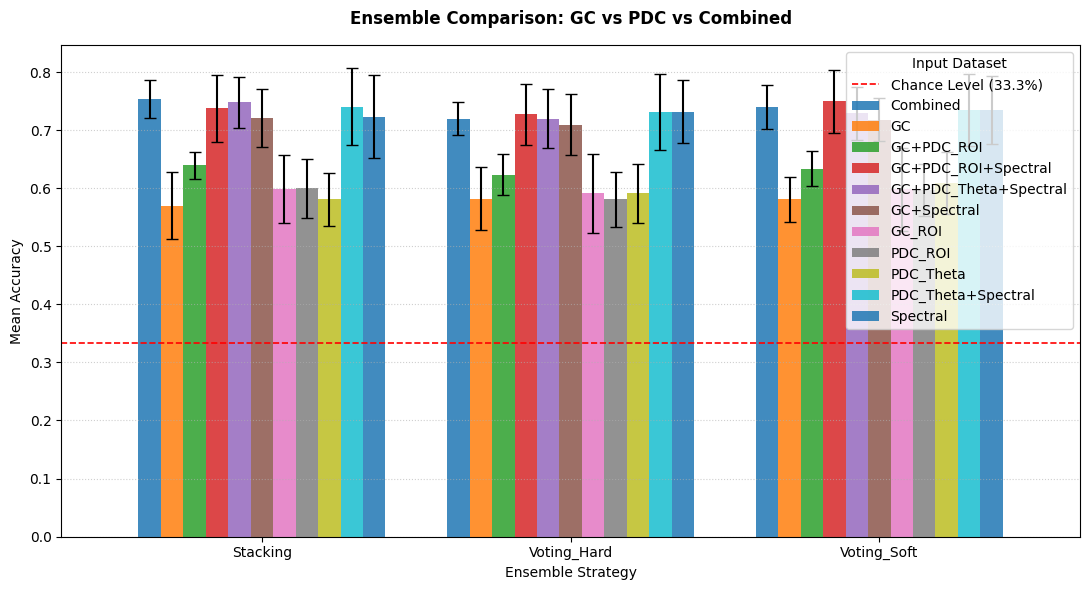

Saved ensemble_comparison.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
df_pivot = df_summary.pivot(index='Model', columns='Dataset', values='Mean_Accuracy')
df_std = df_summary.pivot(index='Model', columns='Dataset', values='Std_Accuracy')
df_pivot.plot(kind='bar', ax=ax, yerr=df_std, capsize=4, width=0.8, alpha=0.85)
ax.set_ylabel('Mean Accuracy')
ax.set_xlabel('Ensemble Strategy')
ax.set_title('Ensemble Comparison: GC vs PDC vs Combined', fontweight='bold', pad=15)
ax.axhline(y=1/3, color='red', linestyle='--', linewidth=1.2, label='Chance Level (33.3%)')
ax.legend(title='Input Dataset', loc='upper right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ensemble_comparison.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved ensemble_comparison.png")


In [6]:
print("="*70)
print("4.5 ENSEMBLE COMPLETE")
print("="*70)
best = df_summary.iloc[0]
print(f"Best: {best['Dataset']} + {best['Model']} -> Acc={best['Mean_Accuracy']:.4f}+/-{best['Std_Accuracy']:.4f}")
print(f"Outputs saved in: {OUTPUT_DIR}")
print(f"Figures saved in: {FIG_DIR}")


4.5 ENSEMBLE COMPLETE
Best: Combined + Stacking -> Acc=0.7541+/-0.0329
Outputs saved in: D:\Skripsi\new_data\phase_4_classification\4.5_ensemble\output
Figures saved in: D:\Skripsi\new_data\phase_4_classification\4.5_ensemble\figures
